# Experiment #1: Lexical Baseline (TF-IDF + Random Forest)

**Objective:** To evaluate text classification accuracy based on lexical features (word frequencies). 
This method serves as a primary **Baseline** for the AI-generated text detection task, helping us understand how well "Bag-of-Words" models perform before moving to complex syntactic analysis.

In [1]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, confusion_matrix)

# Path configuration
DATA_PATH = '../data/ai_detection_ru_dataset_v4.csv'
OUTPUT_DIR = 'output/'
OUTPUT_METRICS = 'output/metrics_tfidf_rf.json'


### 1. Data Loading and Splitting
In this step, we load the pre-processed dataset and split it into training and testing sets (80/20). 
We use `stratify` to maintain the class balance and `random_state=42` for reproducibility across all experiments.

In [2]:
if not os.path.exists(DATA_PATH):
    print(f"File not found: {DATA_PATH}")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset loaded. Total samples: {df.shape[0]}")
    
    # Splitting into train and test sets
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        df['text'], 
        df['is_ai'], 
        test_size=0.2, 
        random_state=42, 
        stratify=df['is_ai']
    )

Dataset loaded. Total samples: 10000


### 2. Feature Extraction (TF-IDF)
We convert raw text into numerical vectors using **Term Frequency-Inverse Document Frequency**. 
By setting `ngram_range=(1, 2)`, we capture both individual words and common word pairs (bigrams).

In [3]:
# Custom stop words to mitigate thematic bias (news agency markers)
custom_stop_words = ['риа', 'новости', 'сообщает', 'говорится', 'ранее', 'рф', 'года', '2019']

vectorizer = TfidfVectorizer(max_features=2000, min_df=5, ngram_range=(1, 2),stop_words=custom_stop_words)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)} features.")

Vocabulary size: 2000 features.


### 3. Random Forest Classifier Training
We train a Random Forest ensemble. This model is robust against overfitting and handles high-dimensional sparse matrices effectively.

In [4]:
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
print("Model training successfully completed.")

Model training successfully completed.


### 4. Evaluation and Visualization
We evaluate the model using a comprehensive set of metrics: **Accuracy, Precision, Recall, F1-Score, and AUC-ROC**. Visualizations include the Confusion Matrix, ROC Curve, and Precision-Recall Curve to assess the model's robustness at different classification thresholds.

-----------------------------------
Metric          | Value     
-----------------------------------
Accuracy        | 0.9660
Precision       | 0.9698
Recall          | 0.9620
F1              | 0.9659
AUC-ROC         | 0.9948
-----------------------------------


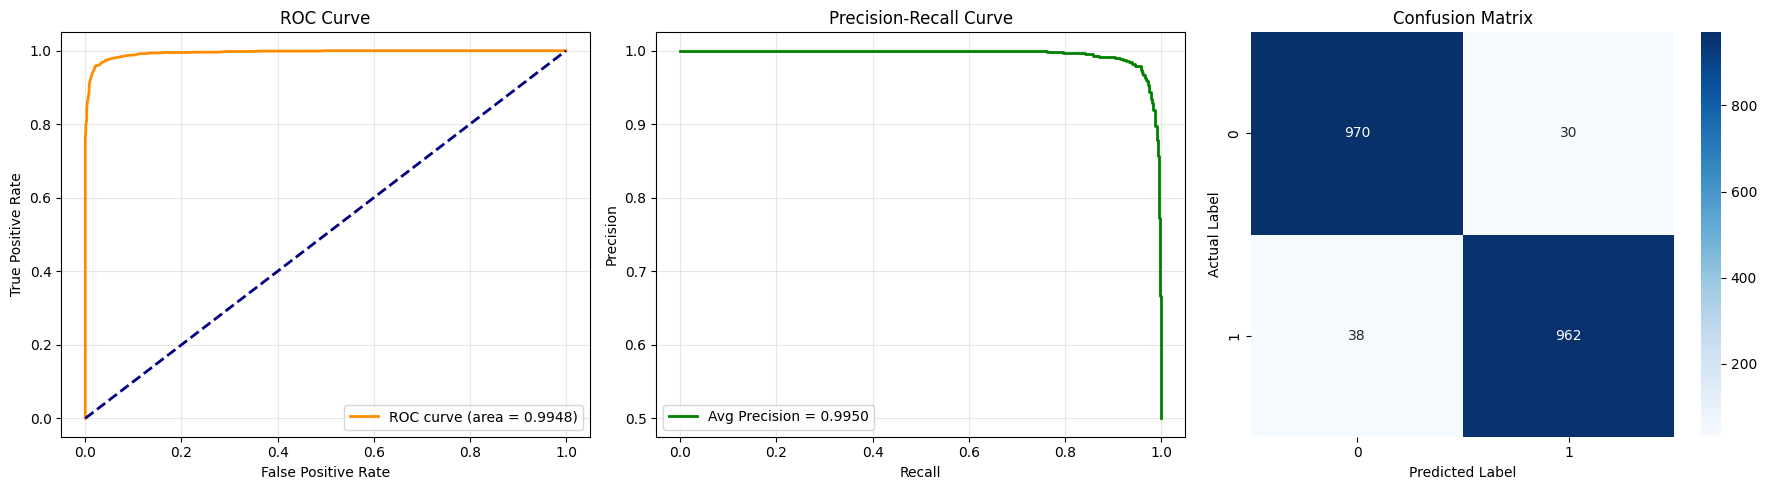

In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

exp_id = 'tfidf_rf'
# Collecting metrics
metrics = {
    "name": "TF-IDF + Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_prob)
}

# Saving results for the final comparison report
with open(OUTPUT_METRICS, 'w') as f:
    json.dump(metrics, f, indent=4)

np.save(os.path.join(OUTPUT_DIR, f'y_prob_{exp_id}.npy'), y_prob)
np.save(os.path.join(OUTPUT_DIR, f'y_true_{exp_id}.npy'), y_test)

# Print Summary Table
print("-" * 35)
print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 35)
for k, v in metrics.items():
    if k != "name":
        print(f"{k:<15} | {v:.4f}")
print("-" * 35)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ROC-curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {metrics["AUC-ROC"]:.4f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_p = average_precision_score(y_test, y_prob)
ax[1].step(recall, precision, where='post', color='green', lw=2, label=f'Avg Precision = {avg_p:.4f}')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[2])
ax[2].set_title('Confusion Matrix')
ax[2].set_ylabel('Actual Label')
ax[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [6]:
importances = model.feature_importances_
feature_names = vectorizer.get_feature_names_out()

indices = np.argsort(importances)[-20:]

print("Top 20 words that define AI/Human:")
for i in reversed(indices):
    print(f"{feature_names[i]}: {importances[i]:.4f}")

Top 20 words that define AI/Human:
об: 0.0207
на: 0.0177
об этом: 0.0172
этом: 0.0148
включая: 0.0139
для: 0.0115
однако: 0.0112
является: 0.0110
при: 0.0093
данные ситуации: 0.0088
ситуации covid: 0.0082
рассказал: 0.0080
эксперты: 0.0079
россии мире: 0.0076
также: 0.0073
до: 0.0072
за: 0.0070
сообщении: 0.0070
сказал: 0.0069
сообщил: 0.0065


## Experiment #1 Analysis: Summary and Observations

### Performance Metrics
The **TF-IDF + Random Forest** baseline achieved outstanding results across all key metrics:
* **Accuracy (0.9660)** and **F1-Score (0.9659)** indicate a high overall classification success.
* **AUC-ROC (0.9948)** demonstrates that the model has a near-perfect ability to distinguish between Human and AI classes.

### Discussion and Potential Bias
While these metrics suggest a solved problem, a deeper look into the **Feature Importance** reveals a significant **Genre Bias**. The model heavily relies on lexical markers such as *"сообщает"* (reports), *"риа"* (RIA), and *"говорится"* (stated). 

This implies that the model is primarily identifying **News Reporting Style** (typical for the human-written subset) rather than the intrinsic nature of AI generation. 

### Conclusion for the Research Project
1. **Baseline Strength:** Lexical features are highly effective for this specific dataset but may lack generalizability.
2. **Next Steps:** To improve the robustness of detection and fulfill the thesis objectives, the research will shift towards **Stylometric and Syntactic Anomaly Analysis**. These features (punctuation density, sentence structure) are expected to be more "genre-agnostic" and focus on the technical signatures of LLM output.